# Apply syndrome-based decoding technique for BCH(15,7) codes

In [1]:
import numpy as np
import pyldpc as ldpc
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
import os.path, sys, bz2
%matplotlib inline
%config InlineBackend.figure_format='retina'

In [2]:
k = 7
N = 15
T = 2

In [3]:
def getBinaryMatrix(source):
    source = os.path.expanduser(source)
    fileObj = bz2.BZ2File(source, 'r') if source.endswith('bz2') else open(source, 'rt')
    with fileObj as f:
        lines = [[int(x) for x in l.strip().split()]
                  for l in f.readlines()
                  if len(l.strip()) > 0]

    if lines[0][0] in (0, 1):  # explicit 0/1 representation
        return np.array(lines, dtype=np.int)
    return alistToNumpy(lines)

def alistToNumpy(lines):
    nCols, nRows = lines[0]
    if len(lines[2]) == nCols and len(lines[3]) == nRows:
        startIndex = 4
    else:
        startIndex = 2
    matrix = np.zeros((nRows, nCols), dtype=int)
    for col, nonzeros in enumerate(lines[startIndex:startIndex + nCols]):
        for rowIndex in nonzeros:
            if rowIndex != 0:
                matrix[rowIndex - 1, col] = 1
    return matrix

In [4]:
# Create gen and parity check matrices
H = getBinaryMatrix('source/BCH_15_7_2_strip.alist')
G = ldpc.coding_matrix(H, sparse=False).T

In [5]:
def full_adder(a,b,c):
    s = (a ^ b) ^ c
    c = (a & b) | (c & (a ^ b))
    return s,c

def add_bool(a,b):
    if len(a) != len(b):
        raise ValueError('arrays with different length')
    k = len(a)
    s = np.zeros(k,dtype=bool)
    c = False
    for i in reversed(range(0,k)):
        s[i], c = full_adder(a[i],b[i],c)    
    if c:
        warnings.warn("Addition overflow!")
    return s

def inc_bool(a):
    k = len(a)
    increment = np.hstack((np.zeros(k-1,dtype=bool), np.ones(1,dtype=bool)))
    a = add_bool(a,increment)
    return a

In [6]:
# Generate information and code words
inputs = np.zeros((2**k,k),dtype=bool)
for i in range(1,2**k):
    inputs[i]= inc_bool(inputs[i-1])
codewords = inputs @ G % 2

In [7]:
# Generate array with all possible 15-bit combinations
combinations = np.zeros((2**N,N),dtype=bool)
for i in range(1,2**N):
    combinations[i] = inc_bool(combinations[i-1])

In [8]:
# Syndrome can take value in range from b00000000 to b11111111, so zero axis of matrix must have size of 256.
# Possible channel values will be assigned to the 1st and 2nd axis of the matrix.
# Initial matrix is filled with inf valeus
errors_sorted = np.full((2**(N-k), 2**N, N), np.inf)
for i, elem in enumerate(combinations):
    synd = int(np.packbits((elem @ H.T % 2), bitorder='little'))     # Calculate syndrom and convert in to int index 
    errors_sorted[synd][i] = elem                                    # Distribute possible channel states according to syndrom values

In [9]:
# Find error vectors with lowest weight in the sorted matrix
# for i in range(0, errors_sorted.shape[0]):
#     print(i, np.argmin(np.sum(errors_sorted, axis=2)[i]), np.min(np.sum(errors_sorted, axis=2)[i]), errors_sorted[i][np.argmin(np.sum(errors_sorted, axis=2)[i])])

# Create lookup table: syndromes - error vector with the least weight
errors = np.zeros((2**(N-k), N), dtype=int)
for i in range(0, 2**(N-k)):
    errors[i] = errors_sorted[i][np.argmin(np.sum(errors_sorted, axis=2)[i])]

# Simulate and plot BER

In [10]:
class ProgressParallel(Parallel):
    def __init__(self, use_tqdm=True, total=None, desc='', *args, **kwargs):
        self._use_tqdm = use_tqdm
        self._total = total
        self._desc = desc
        super().__init__(*args, **kwargs)

    def __call__(self, *args, **kwargs):
        with tqdm(disable=not self._use_tqdm, total=self._total, desc=self._desc) as self._pbar:
            return Parallel.__call__(self, *args, **kwargs)

    def print_progress(self):
        if self._total is None:
            self._pbar.total = self.n_dispatched_tasks
        self._pbar.n = self.n_completed_tasks
        self._pbar.refresh()


def simulate(sigmas, max_errors, experiment_func, k , N):
    
    def simulation(sigma):
        nb_bit_errors, nb_frame_errors, nb_bits, nb_frames = 0, 0, 0, 0
        while nb_bit_errors < max_errors:
            res_ber, res_fer = experiment_func(sigma)
            nb_bit_errors += res_ber
            nb_frame_errors += res_fer
            nb_bits += k
            nb_frames += 1
        return nb_bit_errors / nb_bits, nb_frame_errors / nb_frames
    
    ber, fer = np.hsplit(np.asarray(ProgressParallel(n_jobs=-1, total=len(sigmas))([delayed(simulation)(sigma) for sigma in sigmas])), 2)
    return ber, fer

In [11]:
def encode(x):
    return x @ G % 2

def modulateBPSK(x):
    return -2*x +1;

def addNoise(x, sigma):
    w = np.random.normal(loc=0, scale=sigma, size=(N,))
    return x + w

def demodulateBPSK(x):
    return (-(np.sign(x) - 1)/2).astype(int)

def decode(x):
    synd_idx = int(np.packbits((x.astype(int) @ H.T % 2), bitorder='little'))
    cw =  x.astype(bool) ^ errors[synd_idx].astype(bool)
    return cw[N-k:]

def syndrome_decoder(sigma):
    idx = np.random.randint(0, 2**k)
    cw = encode(inputs[idx])
    s = modulateBPSK(cw)
    y = addNoise(s, sigma)
    y = demodulateBPSK(y)
    x_hat = decode(y)
    return np.sum(np.not_equal(inputs[idx], x_hat).astype(int)), np.any(np.not_equal(inputs[idx], x_hat))

In [12]:
test_size = 10**5

SNR_dB_start_Eb = -10
SNR_dB_stop_Eb = 8
SNR_points = 18

SNR_dB_start_Es = SNR_dB_start_Eb + 10*np.log10(k/N)
SNR_dB_stop_Es = SNR_dB_stop_Eb + 10*np.log10(k/N)

sigma_start = np.sqrt(1/(2*10**(SNR_dB_start_Es/10)))
sigma_stop = np.sqrt(1/(2*10**(SNR_dB_stop_Es/10)))
sigmas = np.linspace(sigma_start, sigma_stop, SNR_points)

In [ ]:
ber, fer = simulate(sigmas, test_size, syndrome_decoder, k, N)

  0%|          | 0/18 [00:00<?, ?it/s]

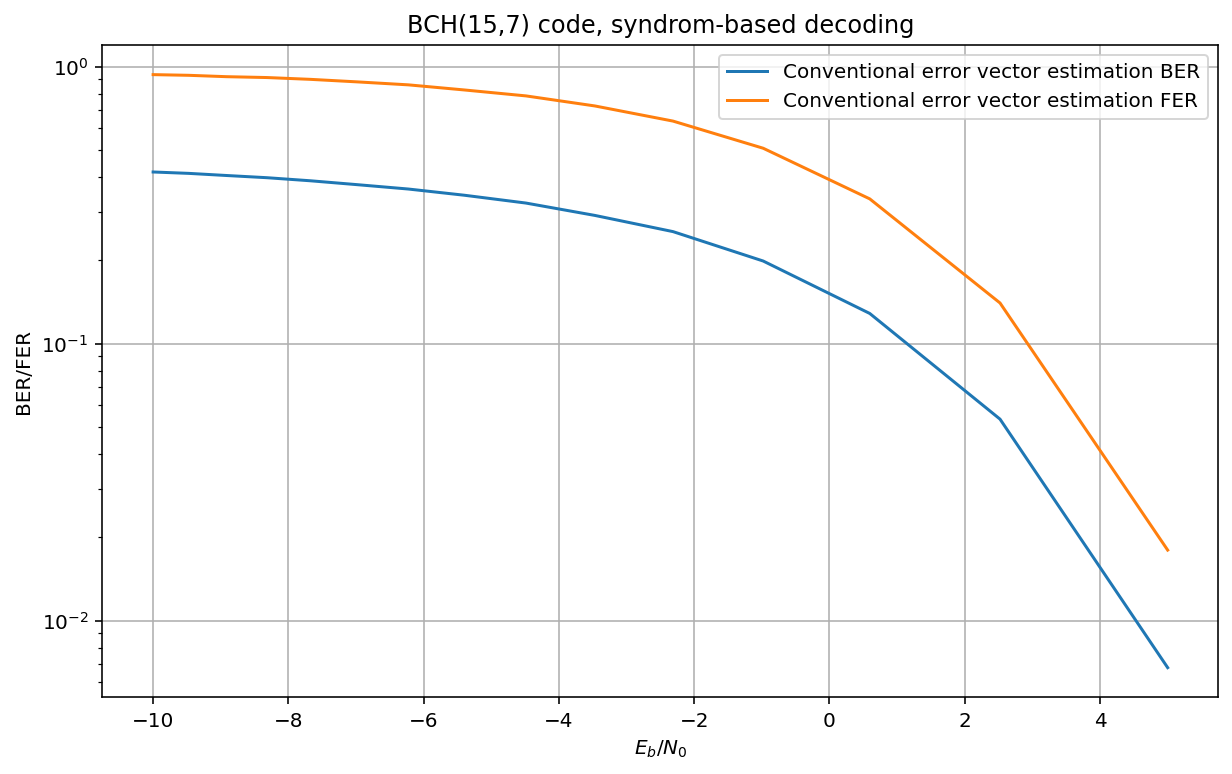

In [14]:
plt.figure(figsize = (10, 6))
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), ber)
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), fer)
plt.legend(['Conventional error vector estimation BER',
            'Conventional error vector estimation FER'])
plt.yscale('log')
plt.xlabel('$E_b/N_0$')
plt.ylabel('BER/FER')
plt.title('BCH(15,7) code, syndrom-based decoding')
plt.grid()

In [15]:
np.savetxt('results/conventional_syndrome_BCH157_-10_5_ber.txt', ber)

In [16]:
np.savetxt('results/conventional_syndrome_BCH157_-10_5_fer.txt', fer)

In [17]:
np.savetxt('results/conventional_syndrome_BCH157_-10_5_sigmas.txt', sigmas)